# AI/ML Task 2: Feature Engineering, Model Optimization & Performance Comparison

**Dataset:** California Housing Dataset (from scikit-learn)
**Objective:** Train and compare Linear Regression, Ridge Regression, and Decision Tree Regressor models.
**Author:** Internship Submission

## 1. Import Libraries
Importing required libraries for data manipulation, visualization, and machine learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
import os

# Create directories for saving results
os.makedirs('../report', exist_ok=True)
os.makedirs('../plots', exist_ok=True)

## 2. Load Dataset
Loading the California Housing Dataset from scikit-learn and creating a Pandas DataFrame.

In [2]:
# Load the dataset
california = fetch_california_housing()
df = pd.DataFrame(california.data, columns=california.feature_names)
df['MedHouseVal'] = california.target

# Display the first few rows
display(df.head())

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## 3. Exploratory Data Analysis (EDA)
Understanding the dataset shape, missing values, descriptive statistics, and feature correlations.

In [3]:
# Dataset Shape and Info
print(f"Dataset Shape: {df.shape}\n")
print("Dataset Info:")
df.info()

Dataset Shape: (20640, 9)

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [4]:
# Missing Values
print("Missing Values in each column:")
print(df.isnull().sum())

Missing Values in each column:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


In [5]:
# Descriptive Statistics
print("Descriptive Statistics:")
display(df.describe())

Descriptive Statistics:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


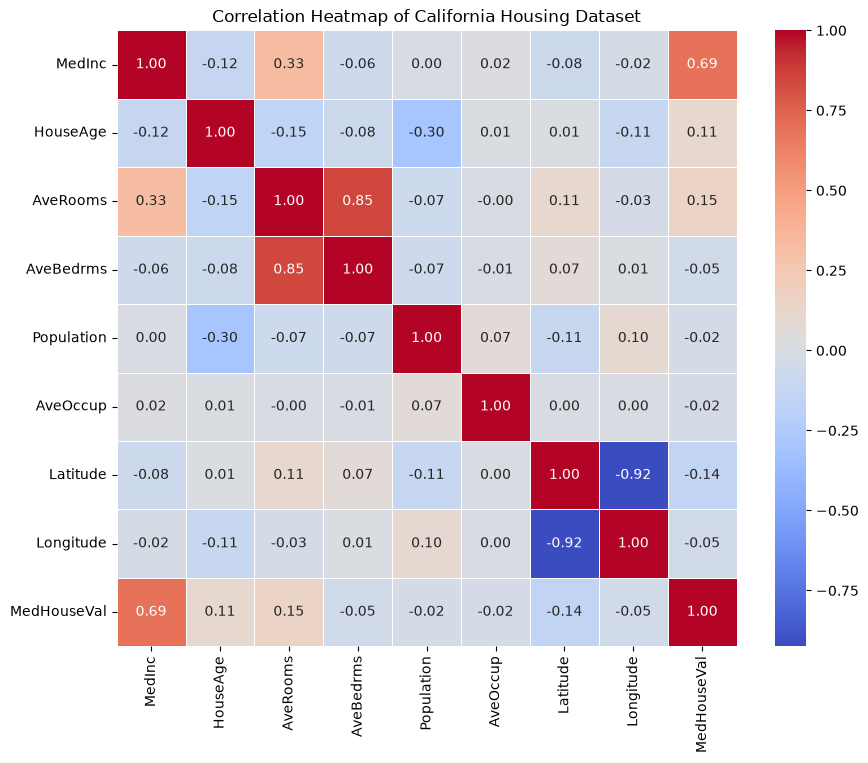

In [6]:
# Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of California Housing Dataset')
plt.show()

## 4. Data Preprocessing
Separating features (X) and target (y), applying StandardScaler for feature scaling, and splitting into training and testing sets (80:20).

In [7]:
# Separate features (X) and target (y)
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

# Split data into training and testing sets (80:20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Apply StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training features shape: {X_train_scaled.shape}")
print(f"Testing features shape: {X_test_scaled.shape}")

Training features shape: (16512, 8)
Testing features shape: (4128, 8)


## 5. Model Training and Evaluation
Training Linear Regression, Ridge Regression, and Decision Tree Regressor. Evaluating them using RMSE and R² Score.

In [8]:
# Initialize models
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Decision Tree Regressor": DecisionTreeRegressor(random_state=42)
}

# Dictionary to store results
results = {}

# Train and Evaluate each model
for name, model in models.items():
    # Train the model
    model.fit(X_train_scaled, y_train)
    
    # Make predictions
    y_pred = model.predict(X_test_scaled)
    
    # Calculate metrics
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    # Store metrics
    results[name] = {"RMSE": rmse, "R2 Score": r2}
    
    # Print metrics clearly
    print(f"--- {name} ---")
    print(f"RMSE: {rmse:.4f}")
    print(f"R² Score: {r2:.4f}\n")

--- Linear Regression ---
RMSE: 0.7456
R² Score: 0.5758

--- Ridge Regression ---
RMSE: 0.7456
R² Score: 0.5758

--- Decision Tree Regressor ---
RMSE: 0.7028
R² Score: 0.6230



## 6. Performance Comparison
Creating a comparison table and identifying the best performing model.

In [9]:
# Create a comparison table (DataFrame)
comparison_df = pd.DataFrame(results).T
comparison_df.reset_index(inplace=True)
comparison_df.rename(columns={'index': 'Model'}, inplace=True)
comparison_df = comparison_df.sort_values(by="RMSE", ascending=True)

print("Model Comparison Table:")
display(comparison_df)

# Save comparison table as CSV
csv_path = '../report/AI_ML_Task2_Comparison_Table.csv'
comparison_df.to_csv(csv_path, index=False)
print(f"\nComparison table successfully saved to: {csv_path}")

Model Comparison Table:


,Model,RMSE,R2 Score
2,Decision Tree Regressor,0.702829,0.623042
1,Ridge Regression,0.745557,0.575816
0,Linear Regression,0.745581,0.575788



Comparison table successfully saved to: ../report/AI_ML_Task2_Comparison_Table.csv


## 7. Best Model Selection
Identify the best performing model based on evaluation metrics.

In [10]:
# Select Best Model
best_model_name = comparison_df.iloc[0]['Model']
best_rmse = comparison_df.iloc[0]['RMSE']
best_r2 = comparison_df.iloc[0]['R2 Score']

print(f"Best Performing Model: **{best_model_name}**")
print(f"Explanation: {best_model_name} was selected because it achieved the lowest RMSE ({best_rmse:.4f}) and highest R² Score ({best_r2:.4f}) among the evaluated models on the test set. This indicates it generalizes better to unseen data compared to the other approaches.")

Best Performing Model: **Decision Tree Regressor**
Explanation: Decision Tree Regressor was selected because it achieved the lowest RMSE (0.7028) and highest R² Score (0.6230) among the evaluated models on the test set. This indicates it generalizes better to unseen data compared to the other approaches.


## 8. Visualization: Actual vs Predicted
Plotting the Actual vs Predicted House Prices for the best-performing model.

Plot successfully saved to: ../plots/Task2_Actual_vs_Predicted.png


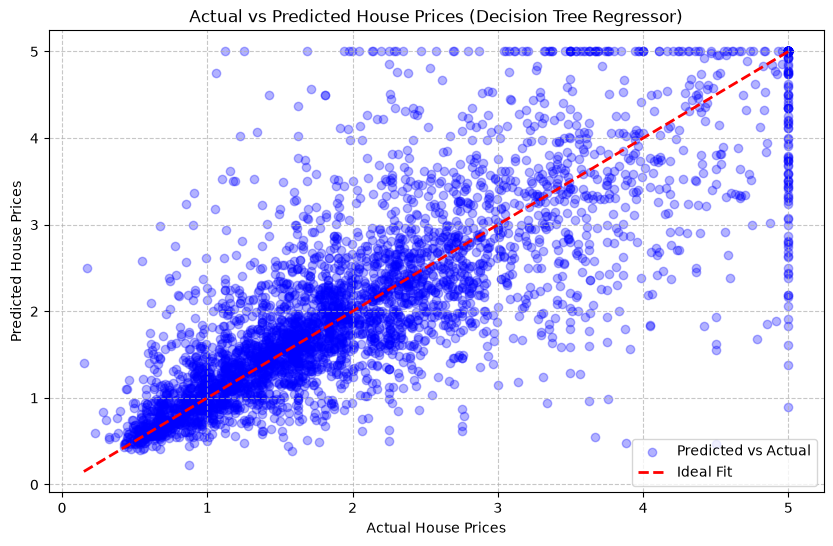

In [11]:
# Use the best model to predict for visualization
best_model = models[best_model_name]
y_pred_best = best_model.predict(X_test_scaled)

# Plot Actual vs Predicted
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_best, alpha=0.3, color='blue', label='Predicted vs Actual')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Ideal Fit')
plt.title(f'Actual vs Predicted House Prices ({best_model_name})')
plt.xlabel('Actual House Prices')
plt.ylabel('Predicted House Prices')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Save the plot as a PNG image
plot_path = '../plots/Task2_Actual_vs_Predicted.png'
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
print(f"Plot successfully saved to: {plot_path}")

plt.show()